Прототип Contract Multi-Agent. Используем LangGraph + GigaChat.

Эта версия написана Alice AI.

##1: Установка зависимостей

In [34]:
!pip install langgraph langchain langchain-gigachat python-dotenv

##2: Импорт библиотек и загрузка ключа

In [ ]:
import os
from langgraph.graph import StateGraph, END
from langchain_gigachat import GigaChat
from dotenv import load_dotenv

load_dotenv()  # если ключ в .env
# Если не используете .env, раскомментируйте и вставьте ключ вручную:
# os.environ["GIGACHAT_TOKEN"] = "ваш_ключ_GigaChat"

giga = GigaChat(
    credentials=os.getenv("GIGACHAT_TOKEN"),
    scope="GIGACHAT_API_PERS",
    verify_ssl_certs=False,
)

##3: Определение состояния графа

In [36]:
from typing import TypedDict, List

class ContractReviewState(TypedDict):
    contract_text: str
    lawyer_findings: str
    finance_findings: str
    final_report: str


##4: Агент-юрист (проверка юридических рисков)

In [37]:
def lawyer_agent(state: ContractReviewState) -> ContractReviewState:
    prompt = (
        "Ты — опытный юрист по договорному праву. Проанализируй текст договора и найди:\n"
        "- спорные формулировки и двусмысленности\n"
        "- риски для стороны (штрафы, сроки, ответственность)\n"
        "- отсутствие обязательных условий\n"
        "Верни краткий, но конкретный список выводов в 5–7 пунктов. Не пиши общих рассуждений.\n\n"
        f"Текст договора:\n{state['contract_text']}"
    )
    response = giga.invoke(prompt)

    return {"lawyer_findings": response.content}


##5: Агент-финансист (проверка финансовых условий)

In [38]:
def finance_agent(state: ContractReviewState) -> ContractReviewState:
    prompt = (
        "Ты — финансовый эксперт. Проанализируй условия договора и найди:\n"
        "- порядок и сроки оплаты\n"
        "- штрафы, пени, курсовые риски\n"
        "- скрытые платежи и условия, влияющие на стоимость\n"
        "- валютные оговорки и риски\n"
        "Верни краткий список выводов в 5–7 пунктов без общих рассуждений.\n\n"
        f"Текст договора:\n{state['contract_text']}"
    )
    response = giga.invoke(prompt)

    return {"finance_findings": response.content}

##6: Формирование итогового отчета

In [39]:
def generate_final_report(state: ContractReviewState) -> ContractReviewState:
    prompt = (
        "Объедини выводы юриста и финансиста в единый отчет для руководителя.\n"
        "Структурируй по блокам: «Юридические риски», «Финансовые риски», «Рекомендации».\n"
        "В рекомендациях укажи 3–5 конкретных действий, которые нужно предпринять.\n\n"
        f"Выводы юриста:\n{state['lawyer_findings']}\n\n"
        f"Выводы финансиста:\n{state['finance_findings']}"
    )
    response = giga.invoke(prompt)

    return {"final_report": response.content}

##  7: Построение графа (LangGraph)

In [40]:
workflow = StateGraph(ContractReviewState)

workflow.add_node("lawyer", lawyer_agent)
workflow.add_node("finance", finance_agent)
workflow.add_node("report", generate_final_report)

# Параллельный запуск юриста и финансиста
workflow.set_entry_point("lawyer")
workflow.add_edge("lawyer", "finance")

# После обоих агентов — финальный отчет
def route_after_agents(state: ContractReviewState):
    # Просто переходим к отчету, когда оба агента сработали
    return "report"

workflow.add_conditional_edges(
    "finance",
    route_after_agents,
    {"report": "report"}
)

workflow.add_edge("report", END)
graph = workflow.compile()


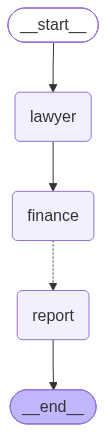

In [41]:
# Визуализация графа (опционально, но очень полезно для отладки)
# Показывает архитектуру нашего мульти-агентного пайплайна.
from IPython.display import display, Image

try:
    png_data = graph.get_graph().draw_mermaid_png()
    display(Image(png_data))
except Exception as e:
    print(f"Не удалось отрисовать граф (возможно, не установлен пакет pyppeteer/graphviz): {e}")
    print("Граф успешно скомпилирован, переходим к тестам.")

##8: Пример договора и запуск

In [42]:
sample_contract = """
Договор поставки №123 от 01.08.2024
Поставщик обязуется поставить товар в течение 10 рабочих дней.
Цена договора: 1 000 000 рублей.
Оплата: 50% предоплата, 50% по факту поставки.
Штраф за просрочку поставки: 0.1% в день от стоимости партии.
Валюта: рубли.
Срок действия договора: до 31.12.2024.
Ответственность сторон регулируется действующим законодательством РФ.
"""

result = graph.invoke({
    "contract_text": sample_contract,
    "lawyer_findings": "",
    "finance_findings": "",
    "final_report": ""
})


print(result["final_report"])

## Отчет руководителю компании

### Блок 1. Юридические риски

#### Недостаточные условия договора

- **Сроки оплаты:** Отсутствие чётких дат/периодов оплаты (предоплата 50%, оставшаяся сумма после поставки), что создаёт высокий риск разногласий и непонимания сторонами порядка расчётов.
- **Ответственность за нарушение сроков оплаты:** В документе не прописаны штрафы и санкции за несвоевременное перечисление аванса, что усиливает финансовую уязвимость стороны-поставщика.
- **Понятие «товара**: Неопределённость формулировки «товар» вызывает риск недопонимания и возможных юридических конфликтов относительно перечня товаров.
- **Недопустимость досрочной поставки:** Точное условие о возможности досрочного исполнения обязательств в договоре отсутствует, увеличивая вероятность конфликта относительно сроков поставки.
- **Расчёт штрафов:** Не указаны детали расчёта штрафа, включая учёт выходных и праздничных дней, что может привести к неправильному определению размера санкций.
- **Форс-мажорны